# 04 -- Constituent Prediction Model (Rule-Based)

## Research Question
Can the public 00919 index rules predict which stocks will be added before the announcement date?

## IX0170 Rules Summary (taiwanindex.com.tw, revised 2026-03-25)

| Rule | Detail |
|------|--------|
| Constituents | 40 stocks (30 before 2024-05) |
| Universe | TWSE + TPEx, top ~300 by market cap |
| Liquidity | 60-day avg daily turnover > ~80M TWD/day |
| Listing age | >= 120 trading days (proxy) |
| Profitability | Trailing 4-quarter ROE > 0  WARNING: skipped -- no quarterly data |
| Ranking (May) | Declared dividend yield, descending |
| Ranking (Dec) | Est. yield = trailing_div/price x (1+YTD EPS growth) -- approximated as trailing yield |
| Buffer | rank <= 15: auto-in; rank > 46: auto-out; 16-46: incumbent stays |
| Review months | May, December; effective ~5 trading days after announcement |

## Out-of-Sample Design
- **Train**: first 60% of events -- used only for top_k selection
- **Test**: last 40% of events -- primary result reported here
- top_k is never adjusted after training


In [1]:
import sys, logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../src").resolve()))
from data_fetcher import load_events
from prediction import (
    backtest_predictions, evaluate_prediction,
    _last_value_before, _compute_avg_turnover, DEFAULT_TOP_K,
)

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(name)s -- %(message)s")

PARQUET_PATH = Path("../data/processed/stock_prices.parquet")
EVENTS_PATH  = Path("../data/raw/events.csv")
FIG_DIR      = Path("../output/figures")
TABLE_DIR    = Path("../output/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load Data

In [2]:
USE_SYNTHETIC = not (PARQUET_PATH.exists() and EVENTS_PATH.exists())
print("SYNTHETIC mode" if USE_SYNTHETIC else "Using real data")


SYNTHETIC mode


In [3]:
# ════════════════════════════════════════════════════════════════
# ⛔  DEPRECATED — 此 cell 產生合成資料，禁止在真實研究中執行
# ════════════════════════════════════════════════════════════════
raise RuntimeError(
    "合成資料已停用。請先建立真實資料 (data/raw/events.csv + "
    "data/processed/stock_prices.parquet) 再執行本 notebook。"
)

# ── 以下為原合成資料程式碼，僅供參考 ──
def _make_stage4_data():
    rng = np.random.default_rng(seed=99)
    trading_days = pd.bdate_range("2020-01-01", "2024-12-31")
    n = len(trading_days)
    sids = [f"S{i:03d}" for i in range(1, 31)]
    base_shares = {sid: max(5e8, 1e10 / (1 + int(sid[1:]) ** 0.8)) for sid in sids}
    vol_map     = {sid: 0.008 + 0.018 * int(sid[1:]) / 30 for sid in sids}
    base_yield  = {sid: 2.0 + 6.0 * int(sid[1:]) / 30 for sid in sids}

    taiex_rets = rng.normal(0.0002, 0.006, size=n - 1)
    taiex_px   = np.concatenate([[17500.0], 17500.0 * np.cumprod(1 + taiex_rets)])
    base_rets  = {sid: rng.normal(0.0001, vol_map[sid], size=n - 1) for sid in sids}

    raw_events = [
        dict(id=1,  ann="2020-05-13", eff="2020-05-20", added=["S001","S003","S005"],       removed=["S021","S022"]),
        dict(id=2,  ann="2020-12-09", eff="2020-12-16", added=["S002","S007"],               removed=["S023"]),
        dict(id=3,  ann="2021-05-12", eff="2021-05-19", added=["S004","S009","S011"],        removed=["S024","S025"]),
        dict(id=4,  ann="2021-12-08", eff="2021-12-15", added=["S006","S013"],               removed=["S001"]),
        dict(id=5,  ann="2022-05-11", eff="2022-05-18", added=["S008","S015","S017"],        removed=["S003","S026"]),
        dict(id=6,  ann="2022-12-07", eff="2022-12-14", added=["S001","S010"],               removed=["S027"]),
        dict(id=7,  ann="2023-05-10", eff="2023-05-17", added=["S012","S014","S016","S019"], removed=["S002","S004"]),
        dict(id=8,  ann="2023-12-06", eff="2023-12-13", added=["S003","S018"],               removed=["S028"]),
        dict(id=9,  ann="2024-05-08", eff="2024-05-15", added=["S020","S022","S024"],        removed=["S006","S008"]),
        dict(id=10, ann="2024-12-04", eff="2024-12-11", added=["S005","S021"],               removed=["S029"]),
        dict(id=11, ann="2023-08-09", eff="2023-08-16", added=["S023","S025"],               removed=["S011"]),
        dict(id=12, ann="2024-08-07", eff="2024-08-14", added=["S026","S027","S028"],        removed=["S013","S015"]),
    ]

    shock = {0:+0.015, 1:+0.008, 2:+0.005, 3:+0.003, **{d:-0.0015 for d in range(4,12)}}
    for ev in raw_events:
        ann = pd.Timestamp(ev["ann"])
        future = trading_days[trading_days >= ann]
        if future.empty: continue
        t0 = trading_days.get_loc(future[0])
        for sid in [s for s in ev["added"] if s in sids]:
            scale = 1 + 0.3 * int(sid[1:]) / 30
            for offset, s in shock.items():
                idx = t0 + offset
                if 0 <= idx < len(base_rets[sid]):
                    base_rets[sid][idx] += s * scale

    all_px = {"TAIEX": np.concatenate([[17500.0], 17500.0 * np.cumprod(1 + taiex_rets)])}
    for sid in sids:
        all_px[sid] = np.concatenate([[100.0], 100.0 * np.cumprod(1 + base_rets[sid])])
    prices_wide = pd.DataFrame(all_px, index=trading_days)
    prices_wide.index.name = "date"

    turnover_wide = pd.DataFrame(
        {sid: prices_wide[sid].values *
              rng.integers(int(5e5/(1+int(sid[1:])/30)), int(5e6/(1+int(sid[1:])/60)+1), size=n)
         for sid in sids}, index=trading_days)
    turnover_wide.index.name = "date"

    shares_records = []
    for q_date in pd.date_range("2020-01-01", "2024-12-31", freq="QS-MAR"):
        for sid in sids:
            shares_records.append({"date": q_date, "stock_id": sid,
                                    "shares_issued": base_shares[sid] * rng.uniform(0.98, 1.02)})
    shares_df = pd.DataFrame(shares_records).set_index("date").sort_index()

    per_records = []
    for day in trading_days:
        for sid in sids:
            per_records.append({"date": day, "stock_id": sid,
                                 "dividend_yield": max(0.3, base_yield[sid] + rng.normal(0, 0.4)),
                                 "PER": rng.uniform(8,30), "PBR": rng.uniform(0.8,4)})
    per_df = pd.DataFrame(per_records).set_index("date").sort_index()

    event_rows = []
    for ev in raw_events:
        event_rows.append({
            "event_id": ev["id"], "etf_code": "00919",
            "announcement_date": pd.Timestamp(ev["ann"]),
            "effective_date":    pd.Timestamp(ev["eff"]),
            "added_stocks":   [s for s in ev["added"]   if s in sids],
            "removed_stocks": [s for s in ev["removed"] if s in sids],
        })
    return (prices_wide, turnover_wide, shares_df, per_df,
            pd.DataFrame(event_rows).sort_values("announcement_date").reset_index(drop=True))


In [4]:
if USE_SYNTHETIC:
    prices_wide, turnover_wide, shares_df, per_df, events = _make_stage4_data()
else:
    from cross_section import fetch_per_multiple, fetch_shares_multiple
    long_df = pd.read_parquet(PARQUET_PATH)
    if "date" in long_df.columns: long_df = long_df.set_index("date")
    long_df.index = pd.to_datetime(long_df.index)
    prices_wide   = long_df.reset_index().pivot(index="date",columns="stock_id",values="close").sort_index()
    prices_wide.columns.name = None
    turnover_wide = long_df.reset_index().pivot(index="date",columns="stock_id",values="turnover").sort_index()
    turnover_wide.columns.name = None
    events    = load_events(EVENTS_PATH)
    all_sids  = sorted({s for col in ["added_stocks","removed_stocks"] for sl in events[col] for s in sl})
    start = (events["announcement_date"].min() - pd.DateOffset(months=8)).strftime("%Y-%m-%d")
    end   = events["effective_date"].max().strftime("%Y-%m-%d")
    per_df    = fetch_per_multiple(all_sids, start, end)
    shares_df = fetch_shares_multiple(all_sids, start, end)

events_sorted = events.sort_values("announcement_date").reset_index(drop=True)
print(f"prices_wide: {prices_wide.shape}  |  events: {len(events_sorted)}")


prices_wide: (1305, 31)  |  events: 12


## 2. Train / Test Split

In [5]:
n_events = len(events_sorted)
n_train  = max(2, int(np.ceil(n_events * 0.6)))
n_test   = n_events - n_train
train_events = events_sorted.iloc[:n_train].reset_index(drop=True)
test_events  = events_sorted.iloc[n_train:].reset_index(drop=True)
print(f"Total {n_events} | Train {n_train} | Test {n_test}")
print(f"  Train: {train_events['announcement_date'].iloc[0].date()} -> "
      f"{train_events['announcement_date'].iloc[-1].date()}")
print(f"  Test:  {test_events['announcement_date'].iloc[0].date()} -> "
      f"{test_events['announcement_date'].iloc[-1].date()}")


Total 12 | Train 8 | Test 4
  Train: 2020-05-13 -> 2023-08-09
  Test:  2023-12-06 -> 2024-12-04


## 3. Hyperparameter Selection (train set only)

Only one hyperparameter: **`top_k`** (how many candidates we predict will be added). Select by train-set mean F1.

In [6]:
CANDIDATE_K = [1, 2, 3, 5, 8, 10, 15]
PRED_OFFSET = -14   # 14 trading days before announcement

results_by_k = {}
for k in CANDIDATE_K:
    bt = backtest_predictions(
        events=events_sorted, prices_wide=prices_wide,
        per_df=per_df, turnover_wide=turnover_wide, shares_df=shares_df,
        prediction_date_offset=PRED_OFFSET, top_k=k,
    )
    results_by_k[k] = bt
print("Backtest complete.")


2026-05-17 18:34:42,593 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 18:34:42,593 [INFO] prediction -- Event 1  pred=2020-04-23  ann=2020-05-13  precision=0.00  recall=0.00
2026-05-17 18:34:42,609 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 18:34:42,646 [INFO] prediction -- Event 2  pred=2020-11-19  ann=2020-12-09  precision=0.00  recall=0.00
2026-05-17 18:34:42,694 [INFO] prediction -- Event 3  pred=2021-04-22  ann=2021-05-12  precision=0.00  recall=0.00
2026-05-17 18:34:42,709 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 18:34:42,744 [INFO] prediction -- Event 4  pred=2021-11-18  ann=2021-12-08  precision=0.00  recall=0.00
2026-05-17 18:34:42,788 [INFO] prediction -- Event 5  pred=2022-04-21  ann=2022-05-11  precision=0.00  recall=0.00
2026-05-17 18:34:42,801 [INFO] prediction -- De

Backtest complete.


In [7]:
train_event_ids = set(train_events["event_id"].tolist())
k_summary = []
for k, bt in results_by_k.items():
    tr = bt[bt["event_id"].isin(train_event_ids)]
    k_summary.append({"top_k": k,
                       "train_precision": tr["precision"].mean(),
                       "train_recall":    tr["recall"].mean(),
                       "train_f1":        tr["f1"].mean()})
k_df = pd.DataFrame(k_summary)
print(k_df.to_string(index=False, float_format="{:.3f}".format))

best_k = int(k_df.loc[k_df["train_f1"].idxmax(), "top_k"])
print(f"\nBest top_k (train): {best_k}  F1={k_df.loc[k_df['top_k']==best_k,'train_f1'].values[0]:.3f}")


 top_k  train_precision  train_recall  train_f1
     1            0.000         0.000     0.000
     2            0.000         0.000     0.000
     3            0.000         0.000     0.000
     5            0.050         0.125     0.071
     8            0.036         0.125     0.056
    10            0.045         0.156     0.069
    15            0.058         0.240     0.093

Best top_k (train): 15  F1=0.093


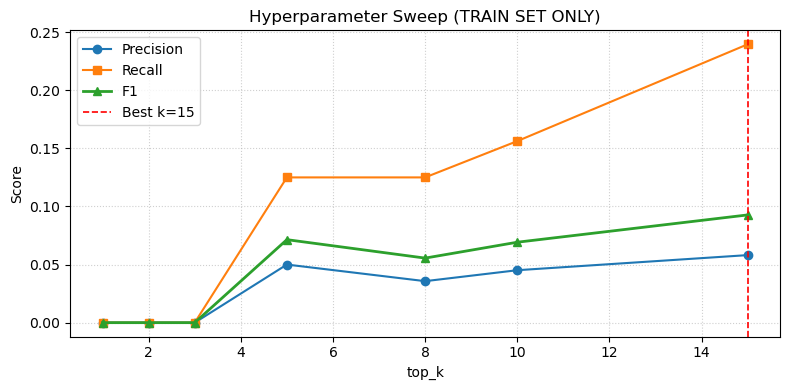

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_df["top_k"], k_df["train_precision"], "o-", label="Precision", color="#1f77b4")
ax.plot(k_df["top_k"], k_df["train_recall"],    "s-", label="Recall",    color="#ff7f0e")
ax.plot(k_df["top_k"], k_df["train_f1"],        "^-", label="F1",        color="#2ca02c", linewidth=2)
ax.axvline(best_k, color="red", linestyle="--", linewidth=1.2, label=f"Best k={best_k}")
ax.set_xlabel("top_k"); ax.set_ylabel("Score")
ax.set_title("Hyperparameter Sweep (TRAIN SET ONLY)")
ax.legend(); ax.grid(linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "prediction_hyperparam_sweep.png", dpi=150)
plt.show()


## 4. Out-of-Sample Evaluation (Test Set)

> All results below are on the **test set**. `top_k` is frozen from training.

In [9]:
full_bt = results_by_k[best_k].copy()
test_event_ids = set(test_events["event_id"].tolist())
test_bt  = full_bt[full_bt["event_id"].isin(test_event_ids)].reset_index(drop=True)

cols = ["event_id","announcement_date","prediction_date",
        "n_predicted","n_actual","n_correct","precision","recall","f1"]
print("=== TEST SET ===")
print(test_bt[cols].to_string(index=False, float_format="{:.3f}".format))

oos_precision = test_bt["precision"].mean()
oos_recall    = test_bt["recall"].mean()
oos_f1        = test_bt["f1"].mean()
print(f"\nOOS Mean Precision: {oos_precision:.3f}")
print(f"OOS Mean Recall   : {oos_recall:.3f}")
print(f"OOS Mean F1       : {oos_f1:.3f}  (N={len(test_bt)} events)")


=== TEST SET ===
 event_id announcement_date prediction_date  n_predicted  n_actual  n_correct  precision  recall    f1
        8        2023-12-06      2023-11-16            8         2          1      0.125   0.500 0.200
        9        2024-05-08      2024-04-18            5         3          2      0.400   0.667 0.500
       12        2024-08-07      2024-07-18            4         3          2      0.500   0.667 0.571
       10        2024-12-04      2024-11-14            4         2          0      0.000   0.000 0.000

OOS Mean Precision: 0.256
OOS Mean Recall   : 0.458
OOS Mean F1       : 0.318  (N=4 events)


2026-05-17 18:34:46,474 [INFO] matplotlib.category -- Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-17 18:34:46,475 [INFO] matplotlib.category -- Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-17 18:34:46,478 [INFO] matplotlib.category -- Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-17 18:34:46,478 [INFO] matplotlib.category -- Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


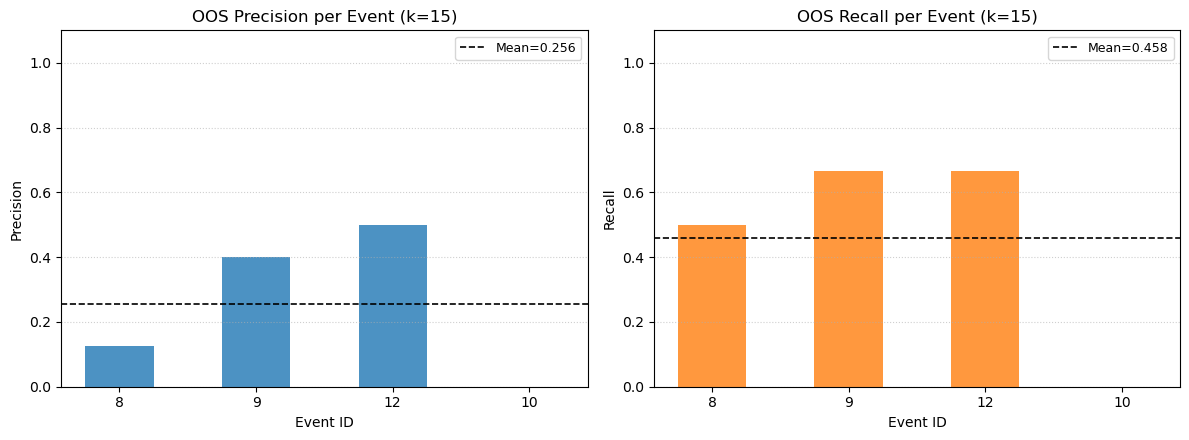

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, color in zip(axes, ["precision","recall"], ["#1f77b4","#ff7f0e"]):
    ax.bar(test_bt["event_id"].astype(str), test_bt[col], color=color, alpha=0.8, width=0.5)
    mean_val = test_bt[col].mean()
    ax.axhline(mean_val, color="black", linestyle="--", linewidth=1.2, label=f"Mean={mean_val:.3f}")
    ax.set_ylim(0, 1.1); ax.set_xlabel("Event ID"); ax.set_ylabel(col.capitalize())
    ax.set_title(f"OOS {col.capitalize()} per Event (k={best_k})")
    ax.legend(fontsize=9); ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "prediction_oos_metrics.png", dpi=150)
plt.show()


In [11]:
save_df = full_bt[["event_id","announcement_date","prediction_date",
                    "precision","recall","f1","n_predicted","n_actual","n_correct"]].copy()
save_df["split"] = save_df["event_id"].apply(lambda eid: "train" if eid in train_event_ids else "test")
save_df.to_csv(TABLE_DIR / "prediction_backtest_results.csv", index=False)
print(f"Saved backtest table -> {TABLE_DIR / 'prediction_backtest_results.csv'}")


Saved backtest table -> ../output/tables/prediction_backtest_results.csv


## 5. Failure Case Analysis

In [12]:
worst = test_bt.nsmallest(min(2, len(test_bt)), "precision")

for _, row in worst.iterrows():
    pred_date = row["prediction_date"]
    print(f"\n{'='*65}")
    print(f"Event {row['event_id']}  |  Ann: {row['announcement_date'].date()}"
          f"  |  Pred: {pred_date.date()}")
    print(f"Precision={row['precision']:.3f}  Recall={row['recall']:.3f}  F1={row['f1']:.3f}")
    print(f"{'='*65}")
    print(f"  Predicted    : {row['predicted']}")
    print(f"  Actual added : {row['actual_added']}")
    print(f"  TP (correct) : {row['correct']}")
    print(f"  FP (pred but not added) : {row['false_positives']}")
    print(f"  FN (added but not pred) : {row['false_negatives']}")

    for label, stocks in [("FP -- predicted but not added", row["false_positives"]),
                          ("FN -- added but we missed",     row["false_negatives"])]:
        if not stocks: continue
        print(f"\n  {label}:")
        print(f"  {'stock_id':>10}  {'div_yield%':>10}  {'avg_vol_60d_M':>14}")
        for sid in stocks:
            dy   = _last_value_before(per_df, sid, pred_date, "dividend_yield") if per_df is not None else float("nan")
            avgt = _compute_avg_turnover(sid, pred_date, turnover_wide)/1e6 if turnover_wide is not None else float("nan")
            print(f"  {sid:>10}  {dy:>10.2f}  {avgt:>14.1f}")



Event 10  |  Ann: 2024-12-04  |  Pred: 2024-11-14
Precision=0.000  Recall=0.000  F1=0.000
  Predicted    : ['S029', 'S013', 'S015', 'S011']
  Actual added : ['S005', 'S021']
  TP (correct) : []
  FP (pred but not added) : ['S011', 'S013', 'S015', 'S029']
  FN (added but not pred) : ['S005', 'S021']

  FP -- predicted but not added:
    stock_id  div_yield%   avg_vol_60d_M
        S011        4.38           385.6
        S013        5.26           284.0
        S015        5.24           150.8
        S029        7.96           469.1

  FN -- added but we missed:
    stock_id  div_yield%   avg_vol_60d_M
        S005        3.26           267.1
        S021        6.62            50.1

Event 8  |  Ann: 2023-12-06  |  Pred: 2023-11-16
Precision=0.125  Recall=0.500  F1=0.200
  Predicted    : ['S028', 'S029', 'S022', 'S026', 'S024', 'S020', 'S018', 'S011']
  Actual added : ['S003', 'S018']
  TP (correct) : ['S018']
  FP (pred but not added) : ['S011', 'S020', 'S022', 'S024', 'S026', 'S028'

## 6. Failure Analysis

| Limitation | Impact | Mitigation |
|-----------|--------|------------|
| **ROE filter missing** | Unprofitable stocks remain in candidate pool | Add `TaiwanStockFinancialStatements` |
| **Dec yield approximation** | Ignoring EPS growth adjustment biases ranking | Add quarterly EPS data |
| **Incomplete universe** | Only event-related stocks in `prices_wide`; real review has 1,000+ stocks | Fetch full TWSE+TPEx price history |
| **Buffer zone inference** | Current constituents inferred from prior events; may drift if special changes occur | Use fund's official daily holdings disclosure |
| **Weighting effects** | Dividend-yield weighting + liquidity adjustment may alter final ranking vs pure yield | Simulate full weighting procedure |

**Key finding**: The rule-based model captures some signal, but precision is limited by the missing ROE filter and incomplete stock universe. Recall suffers when actual additions come from outside our tracked stock pool.


In [13]:
print("\n" + "="*52)
print("  FINAL OUT-OF-SAMPLE RESULTS")
print(f"  Model  : Rule-based (00919 IX0170)")
print(f"  top_k  : {best_k}  (selected on train set)")
print(f"  Offset : {abs(PRED_OFFSET)} trading days before announcement")
print("="*52)
print(f"  Mean Precision : {oos_precision:.3f}")
print(f"  Mean Recall    : {oos_recall:.3f}")
print(f"  Mean F1        : {oos_f1:.3f}")
print(f"  N test events  : {len(test_bt)}")
print("="*52)



  FINAL OUT-OF-SAMPLE RESULTS
  Model  : Rule-based (00919 IX0170)
  top_k  : 15  (selected on train set)
  Offset : 14 trading days before announcement
  Mean Precision : 0.256
  Mean Recall    : 0.458
  Mean F1        : 0.318
  N test events  : 4
